# Task1 仿真平台调用引擎的有效性


## 参考运行结果

直接调用 QuTiP/QuantumOptics/QuantumToolbox 等软件的参考代码，不通过 qsim 的仿真平台

In [18]:
import subprocess, json, sys
from pathlib import Path

REFERENCE_DIR = Path("references") 
JULIA_BIN = "julia"

def run_reference(cmd):
    return json.loads(subprocess.run(cmd, capture_output=True, text=True, encoding="utf-8", check=True).stdout)

res_refs = {}

res_refs["qutip"] = run_reference(
    [sys.executable, f"{REFERENCE_DIR}/task1_qutip_native_reference.py"]
)
res_refs["julia_qoptics"] = run_reference(
    [JULIA_BIN, f"{REFERENCE_DIR}/task1_quantumoptics_native_reference.jl"]
)
res_refs["julia_quantumtoolbox"] = run_reference(
    [JULIA_BIN, f"{REFERENCE_DIR}/task1_quantumtoolbox_native_reference.jl"]
)


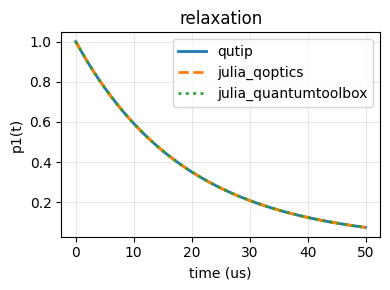

In [19]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(4, 3))
ax = plt.axes()

styles = ["-", "--", ":"]
case_name = "relaxation"

for (engine_name, payload), style in zip(res_refs.items(), styles):
    case = payload["cases"][case_name]
    ax.plot(
        case["times"], case["p1_t"], 
        label=engine_name, linewidth=2, linestyle=style,
    )

    ax.set_title(case_name)
    ax.set_xlabel("time (us)")
    ax.set_ylabel("p1(t)")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


## 调用 qsim

通过 qsim，调用三个引擎，进行同样的仿真模拟

In [20]:
from qsim.workflow import run_task_files
from pathlib import Path

ROOT = Path.cwd().parents[1]
TASK_DIR   = (ROOT / "examples" / "noise_simulation_tests" / "required_tasks").resolve()
SOLVER_DIR = (ROOT / "templates" / "solvers").resolve()
PULSE_DIR  = (ROOT / "templates" / "pulses").resolve()
DEVICE_DIR = (ROOT / "templates" / "devices").resolve()

out_qutip = run_task_files(
    task_config=f"{TASK_DIR}/task1_single_qubit.json",
    solver_config=f"{SOLVER_DIR}/qutip.json",
    pulse_config=f"{PULSE_DIR}/single_qubit.json",
    device_config=f"{DEVICE_DIR}/single_qubit.json",
)


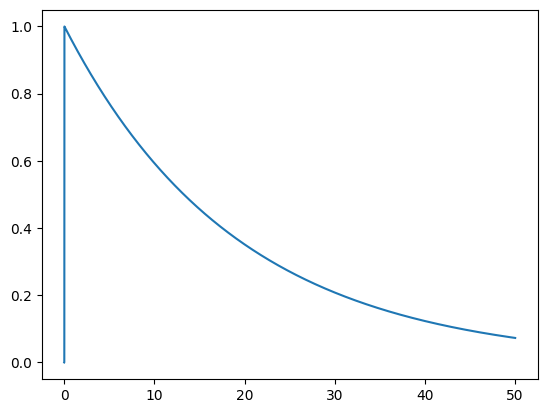

In [21]:
import matplotlib.pyplot as plt
import numpy as np

tr = out_qutip["core"]["trace"]
plt.plot( 1e6 * np.array(tr.times), np.array(tr.states))

In [23]:

out_qoptics = run_task_files(
    task_config=f"{TASK_DIR}/task1_single_qubit.json",
    solver_config=f"{SOLVER_DIR}/julia_qoptics.json",
    pulse_config=f"{PULSE_DIR}/single_qubit.json",
    device_config=f"{DEVICE_DIR}/single_qubit.json",
)

{'analysis': {},
 'sensitivity_report': None,
 'error_budget_v2': None,
 'settings': {'schema_version': '1.0',
  'workflow': {'backend_path': 'D:\\超导量子计算机噪声抑制\\qsim\\templates\\solvers\\julia_qoptics.json',
   'engine_requested': 'julia_qoptics',
   'engine_used': 'julia-quantumoptics',
   'solver': 'me',
   'solver_mode_requested': 'me',
   'allow_mock_fallback': False,
   'compare_engines_requested': [],
   'julia_bin': 'D:\\超导量子计算机噪声抑制\\qsim\\templates\\solvers\\julia',
   'julia_depot_path': '',
   'julia_timeout_s': 120.0,
   'mcwf_ntraj': 128,
   'level': 'qubit',
   'backend_noise_mode': 'lindblad',
   'analysis_pipeline': 'default',
   'seed': 12345,
   'param_bindings': {}},
  'model': {'model_type': 'qubit_network',
   'dimension': 2,
   'num_qubits': 1,
   'model_assumptions': {'qubit_representation': 'two_level_pauli (qubit) or truncated_oscillator (nlevel/cqed)',
    'subsystem_model': 'qubit_network | transmon_nlevel | cqed_jc',
    'truncation_cfg_from_backend': {'transm

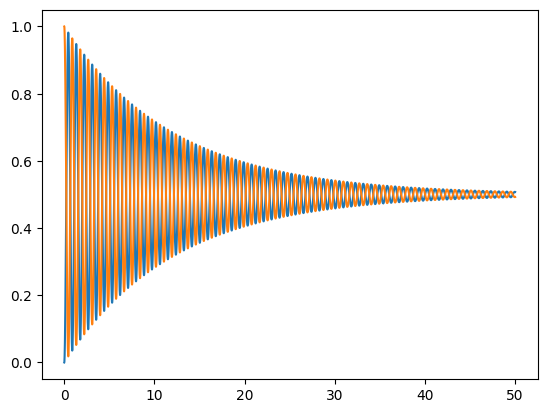

In [30]:

tr = out_qoptics["core"]["trace"]
plt.plot( 1e6 * np.array(tr.times), np.array(tr.states))

out_qoptics["analysis"]